# K-Means Clustering – End-to-End Machine Learning Project

## Project: Wine Data Clustering

K-Means is an **unsupervised machine learning algorithm** used to divide observations into groups called **clusters**.

Observations within the same cluster should be similar, while observations in different clusters should be dissimilar.

The algorithm does not require a predefined target variable `y`.

## Common Applications

- Customer segmentation
- Product grouping
- Document clustering
- Image segmentation
- Patient grouping
- Geographic segmentation
- Pattern discovery

## Main Types of Clustering

### 1. Partition-Based Clustering
Divides data into a predefined number of clusters. **K-Means** is a common example.

### 2. Hierarchical Clustering
Creates a hierarchy of clusters using bottom-up or top-down grouping.

### 3. Density-Based Clustering
Forms clusters from dense regions and can identify noise. **DBSCAN** is a common example.

### 4. Model-Based Clustering
Assumes data is generated from probability distributions. **Gaussian Mixture Models** are a common example.

This project uses **K-Means Clustering**.

## 1. Import Required Libraries

In [1]:
# NumPy is used for numerical operations
import numpy as np

# Pandas is used for data manipulation
import pandas as pd

# Matplotlib is used for visualization
import matplotlib.pyplot as plt

## 2. Load the Wine Dataset

The Wine dataset contains numerical measurements obtained from wine samples.

The dataset also contains known class labels. However, the target labels are **not used for K-Means training** because K-Means is an unsupervised learning algorithm.

In [2]:
# Import the Wine dataset
from sklearn.datasets import load_wine

# Load the dataset
wine = load_wine()

# Convert only input features into a Pandas DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display first 5 rows
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

## 3. Understand the Dataset

In [3]:
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display dataset shape
print("\nDataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0    

### Why is dataset understanding required?

Before clustering, the number of observations, features, data types, numerical ranges, and possible data quality problems must be understood.

K-Means is distance-based. Features with very different scales can strongly affect cluster formation.

## 4. Check Data Quality

In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Display duplicate records
duplicate_rows = df[df.duplicated(keep=False)]

print("\nDuplicate Rows:")
print(duplicate_rows)

# Display data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

Duplicate Rows:
Empty DataFrame
Columns: [alcohol, malic_acid, ash, alcalinity_of_ash, magnesium, total_phenols, flavanoids, nonflavanoid_phenols, proanthocyanins, color_intensity, hue, od280/od315_of_diluted_wines, proline]
Index: []

Data Types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   f

## 5. Create Preprocessing Examples

The original Wine dataset is generally clean.

For preprocessing practice, a **copy** of the dataset is created and a few data quality problems are intentionally introduced.

The original DataFrame is not directly modified during problem creation.

In [5]:
# Create a copy for preprocessing demonstration
df_messy = df.copy()

# Intentionally create missing values
df_messy.loc[2, "alcohol"] = np.nan
df_messy.loc[8, "magnesium"] = np.nan
df_messy.loc[15, "color_intensity"] = np.nan

# Intentionally create duplicate records
df_messy = pd.concat(
    [df_messy, df_messy.iloc[[0, 1]]],
    ignore_index=True
)

# Intentionally create an obvious outlier
df_messy.loc[20, "alcohol"] = 100

print("Messy Dataset Shape:", df_messy.shape)

print(df_messy.head())

Messy Dataset Shape: (180, 13)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2      NaN        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines

## 6. Detect Missing Values

In [6]:
# Check missing values in every column
print("Missing Values:")
print(df_messy.isnull().sum())

# Display rows containing at least one missing value
missing_rows = df_messy[df_messy.isnull().any(axis=1)]

print("\nRows Containing Missing Values:")
print(missing_rows)

Missing Values:
alcohol                         1
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       1
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 1
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Rows Containing Missing Values:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
2       NaN        2.36  2.67               18.6      101.0           2.80   
8     14.83        1.64  2.17               14.0        NaN           2.80   
15    13.63        1.81  2.70               17.2      112.0           2.85   

    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
2         3.24                  0.30             2.81             5.68  1.03   
8         2.98         

## 7. Handle Missing Values Using Median

The **median** is used because it is less affected by extreme values than the mean.

This is useful when numerical data may contain outliers.

In [7]:
# Fill missing numerical values using the median of each column
df_messy = df_messy.fillna(df_messy.median())

# Validate missing value handling
print("Missing Values After Handling:")
print(df_messy.isnull().sum())

Missing Values After Handling:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


## 8. Detect and Remove Duplicate Records

In [8]:
# Check duplicate records
print("Duplicate Records:", df_messy.duplicated().sum())

# Display duplicate records
duplicate_rows = df_messy[df_messy.duplicated(keep=False)]

print("\nDuplicate Rows:")
print(duplicate_rows)

# Remove duplicate records
df_messy = df_messy.drop_duplicates()

# Reset index
df_messy = df_messy.reset_index(drop=True)

print("\nDuplicate Records After Removal:", df_messy.duplicated().sum())

print("Dataset Shape:", df_messy.shape)

Duplicate Records: 2

Duplicate Rows:
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
178    14.23        1.71  2.43               15.6      127.0           2.80   
179    13.20        1.78  2.14               11.2      100.0           2.65   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0          3.06                  0.28             2.29             5.64  1.04   
1          2.76                  0.26             1.28             4.38  1.05   
178        3.06                  0.28             2.29             5.64  1.04   
179        2.76                  0.26             1.28             4.38  1.05   

     od280/od315_of_diluted_wines  proline  
0                            3.92   1065.0  
1                            3.40   1050.0  
178                      

## 9. Outlier Detection Using IQR

The **Interquartile Range (IQR)** method identifies values that are unusually far from the middle portion of the data.

### Formula

**IQR = Q3 - Q1**

**Lower Limit = Q1 - 1.5 × IQR**

**Upper Limit = Q3 + 1.5 × IQR**

Values outside these limits are treated as potential outliers.

In [9]:
# Select alcohol column for outlier demonstration
column_name = "alcohol"

# Calculate first quartile
q1 = df_messy[column_name].quantile(0.25)

# Calculate third quartile
q3 = df_messy[column_name].quantile(0.75)

# Calculate IQR
iqr = q3 - q1

# Calculate lower and upper limits
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Display detected outliers
outliers = df_messy[
    (df_messy[column_name] < lower_limit) |
    (df_messy[column_name] > upper_limit)
]

print("\nOutliers:")
print(outliers)

Q1: 12.362499999999999
Q3: 13.6775
IQR: 1.3150000000000013
Lower Limit: 10.389999999999997
Upper Limit: 15.650000000000002

Outliers:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
20    100.0        1.63  2.28               16.0      126.0            3.0   

    flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
20        3.17                  0.24              2.1             5.65  1.09   

    od280/od315_of_diluted_wines  proline  
20                          3.71    780.0  


## 10. Handle the Demonstration Outlier

The intentionally introduced extreme value is removed using the IQR limits.

Outlier removal should not always be automatic in real projects. Outliers may represent valid rare observations and should be investigated before removal.

In [10]:
# Keep only records within the IQR limits for alcohol
df_messy = df_messy[
    (df_messy[column_name] >= lower_limit) &
    (df_messy[column_name] <= upper_limit)
]

# Reset index
df_messy = df_messy.reset_index(drop=True)

# Use the cleaned dataset
df = df_messy.copy()

print("Dataset Shape After Outlier Handling:", df.shape)

Dataset Shape After Outlier Handling: (177, 13)


## 11. Validate the Cleaned Dataset

In [11]:
# Validate missing values
print("Missing Values:")
print(df.isnull().sum())

# Validate duplicates
print("\nDuplicate Records:", df.duplicated().sum())

# Validate data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Duplicate Records: 0

Data Types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline       

## 12. Select Input Features

K-Means is an unsupervised learning algorithm.

Therefore:

- `x` contains input features.
- There is no target variable `y`.
- `wine.target` is not used for model training.

The objective is to allow K-Means to discover groups from feature similarities.

In [12]:
# Copy all input features into x
x = df.copy()

print(x.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.05        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

## 13. Feature Scaling

K-Means commonly uses **Euclidean Distance**.

The Wine features have different numerical scales. A large-scale feature can dominate the distance calculation.

`StandardScaler` transforms features to comparable scales.

After standardization, each feature has approximately:

- Mean = 0
- Standard Deviation = 1

### Formula

**z = (x - mean) / standard deviation**

In [13]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the input features
x_scaled = scaler.fit_transform(x)

print(x_scaled)

[[ 1.53005895 -0.56488232  0.229683   ...  0.36478347  1.86417763
   1.01078509]
 [ 0.25499817 -0.50215137 -0.82768278 ...  0.4085753   1.12674303
   0.96315056]
 [ 0.06930971  0.01761935  1.10474433 ...  0.32099164  0.80057003
   1.39186137]
 ...
 [ 0.34165278  1.73823965 -0.39015211 ... -1.60584889 -1.48264095
   0.28038889]
 [ 0.21786048  0.22373532  0.01091767 ... -1.56205706 -1.39755234
   0.29626707]
 [ 1.40626664  1.57693149  1.35997056 ... -1.51826523 -1.42591521
  -0.59291091]]


## 14. How K-Means Works

K-Means follows an iterative process:

1. Select the number of clusters `K`.
2. Initialize K cluster centroids.
3. Calculate the distance between observations and centroids.
4. Assign every observation to the nearest centroid.
5. Recalculate each centroid using the mean of assigned observations.
6. Repeat assignment and centroid update.
7. Stop when centroids become stable or the iteration limit is reached.

The objective is to minimize **Within-Cluster Sum of Squares (WCSS)**.

## 15. Important K-Means Terms

### K
The number of clusters.

### Cluster
A group of similar observations.

### Centroid
The center of a cluster.

### WCSS
Within-Cluster Sum of Squares measures the total squared distance between observations and their cluster centroid.

Lower WCSS indicates observations are closer to their centroids.

### Inertia
In Scikit-learn, `inertia_` represents WCSS.

## 16. Elbow Method

K-Means requires the number of clusters before training.

The **Elbow Method** tests different K values and calculates WCSS for each value.

As K increases, WCSS decreases because more centroids are available.

The point where the reduction in WCSS starts slowing significantly is called the **Elbow Point**.

In [14]:
# Import KMeans
from sklearn.cluster import KMeans

# Create an empty list to store WCSS values
wcss = []

# Test K values from 1 to 10
for k in range(1, 11):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    # Train the model
    kmeans.fit(x_scaled)

    # Store WCSS
    wcss.append(kmeans.inertia_)

    print("K:", k, "WCSS:", kmeans.inertia_)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows wi

K: 1 WCSS: 2301.0
K: 2 WCSS: 1650.7991828639074
K: 3 WCSS: 1273.8167838452468
K: 4 WCSS: 1182.4880214629775
K: 5 WCSS: 1105.8718757096015
K: 6 WCSS: 1054.4491483216163
K: 7 WCSS: 980.5814531329372
K: 8 WCSS: 937.0370361650962
K: 9 WCSS: 905.6871061569723
K: 10 WCSS: 855.2910314062754


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 17. Plot the Elbow Method

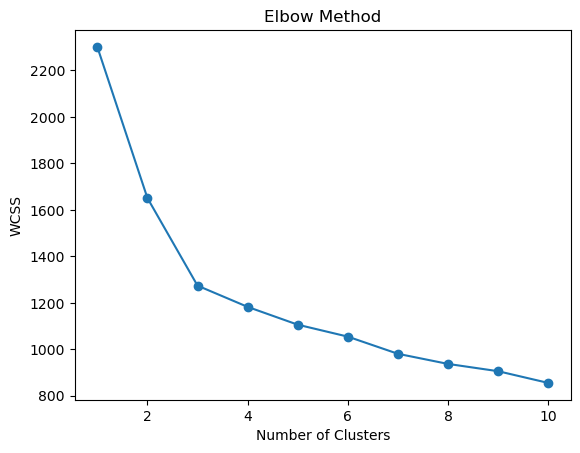

In [15]:
# Plot number of clusters against WCSS
plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

### Elbow Method Interpretation

The graph should be examined for a bend where WCSS reduction changes from rapid to gradual.

K should not be selected only because the original Wine dataset contains known classes.

Clustering evidence must be examined independently.

## 18. Silhouette Score

Silhouette Score evaluates cluster quality using:

**Cohesion:** How close an observation is to its own cluster.

**Separation:** How far an observation is from other clusters.

### Score Range

- Near +1: Well-separated clusters
- Near 0: Overlapping clusters
- Near -1: Poor cluster assignment

Silhouette Score starts from K=2 because a single cluster cannot be compared with another cluster.

In [16]:
# Import Silhouette Score
from sklearn.metrics import silhouette_score

# Create an empty list to store scores
silhouette_scores = []

# Test K values from 2 to 10
for k in range(2, 11):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    # Train model and predict clusters
    labels = kmeans.fit_predict(x_scaled)

    # Calculate Silhouette Score
    score = silhouette_score(x_scaled, labels)

    # Store score
    silhouette_scores.append(score)

    print("K:", k, "Silhouette Score:", score)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows wi

K: 2 Silhouette Score: 0.2676384962351215
K: 3 Silhouette Score: 0.2839251519711716
K: 4 Silhouette Score: 0.2518112895826559
K: 5 Silhouette Score: 0.19964168072228647
K: 6 Silhouette Score: 0.19229226036164496
K: 7 Silhouette Score: 0.19883228506223832
K: 8 Silhouette Score: 0.13192752928292648
K: 9 Silhouette Score: 0.13393401077744954
K: 10 Silhouette Score: 0.13713321436947343


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 19. Plot Silhouette Scores

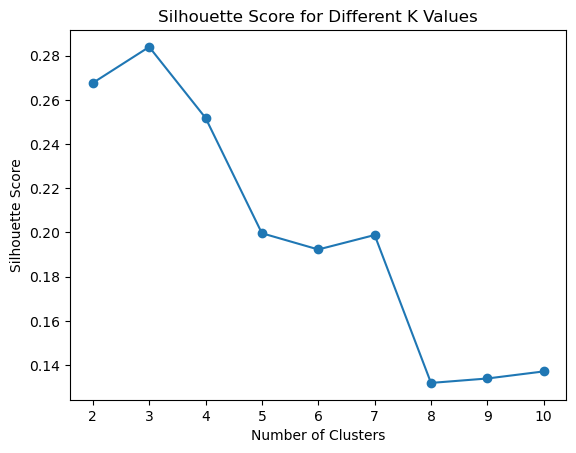

In [17]:
# Plot cluster counts against Silhouette Scores
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

## 20. Select the Final K Value

The Elbow Method examines WCSS reduction.

Silhouette Score examines cluster cohesion and separation.

The final K value should be selected by considering:

- Elbow Method
- Silhouette Score
- Cluster profiles
- Domain knowledge

For this Wine clustering project, **K=3 is selected after examining the clustering evidence from the Elbow Method and Silhouette Score analysis**.

In [18]:
# Based on the Elbow Method and Silhouette Score analysis,
# K=3 is selected as the final number of clusters

selected_k = 3

print("Selected K Value:", selected_k)

Selected K Value: 3


## 21. Create the Final K-Means Model

In [19]:
# Create the final K-Means model

kmeans_model = KMeans(
    n_clusters=selected_k,  # Number of clusters selected from evaluation
    init="k-means++",       # Select better initial centroid positions
    n_init=10,              # Run K-Means 10 times with different initializations
    max_iter=300,           # Maximum iterations for each run
    tol=0.0001,             # Convergence tolerance
    algorithm="lloyd",      # Standard K-Means algorithm
    random_state=42         # Reproducible result
)
print(kmeans_model)

KMeans(n_clusters=3, n_init=10, random_state=42)


### K-Means Parameters

**n_clusters:** Number of clusters to create.

**init="k-means++":** Selects initial centroids more carefully to reduce poor initialization.

**n_init=10:** Runs K-Means multiple times with different centroid initializations and keeps the result with the best inertia.

**max_iter=300:** Maximum number of centroid-update iterations for one K-Means run.

**tol=0.0001:** Convergence tolerance. The algorithm can stop when centroid changes become sufficiently small.

**algorithm="lloyd":** Uses the standard Lloyd K-Means algorithm.

**random_state=42:** Makes the random initialization process reproducible.

## 22. Train the Final Model

In [20]:
# Train the K-Means model using scaled input features

# Only x_scaled is passed because K-Means does not use y
kmeans_model.fit(x_scaled)

print("Model Training Completed")

Model Training Completed


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 23. Predict Cluster Labels

In [21]:
# Assign every observation to its nearest cluster centroid
cluster_prediction = kmeans_model.predict(x_scaled)

print("Cluster Predictions:")
print(cluster_prediction)

Cluster Predictions:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Understanding Cluster Labels

Cluster labels such as 0, 1, and 2 are only identifiers.

Cluster 2 is not greater than Cluster 1.

The meaning of each cluster must be identified using cluster profiling.

## 24. Add Cluster Labels to the DataFrame

In [22]:
# Add predicted cluster labels to the DataFrame
df["Cluster"] = cluster_prediction

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.05        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Cluster  
0         

## 25. Display Cluster Counts

In [23]:
# Count the number of observations in each cluster
print("Cluster Counts:")

print(df["Cluster"].value_counts().sort_index())

Cluster Counts:
Cluster
0    65
1    51
2    61
Name: count, dtype: int64


### Why check Cluster Counts?

Cluster counts show how observations are distributed among clusters.

A very small cluster may represent a rare group, outliers, or an unsuitable clustering structure. Cluster counts should be interpreted with evaluation metrics and cluster profiles.

## 26. Display Cluster Centroids

In [24]:
# Display centroids in scaled feature space
print("Cluster Centers:")

print(kmeans_model.cluster_centers_)

Cluster Centers:
[[-0.91988607 -0.39695639 -0.49504728  0.16472267 -0.48504577 -0.06965718
   0.02730756 -0.03907752  0.06326927 -0.89403967  0.46422461  0.28065682
  -0.75115528]
 [ 0.17344088  0.8665079   0.18464308  0.51859589 -0.0659088  -0.97372759
  -1.20986808  0.7204542  -0.77422991  0.94936202 -1.15934395 -1.28882801
  -0.40536161]
 [ 0.83519851 -0.3014711   0.37313568 -0.60910433  0.57195614  0.88832498
   0.98243083 -0.56070697  0.5798889   0.15893632  0.474622    0.77848419
   1.13932024]]


### What is a Centroid?

A centroid is the center of a cluster.

K-Means recalculates centroids using the mean position of observations assigned to each cluster.

The values displayed above are in **scaled format** because the model was trained using `x_scaled`.

## 27. Convert Centroids to Original Scale

In [25]:
# Convert scaled centroids back to the original feature scale
original_centroids = scaler.inverse_transform(
    kmeans_model.cluster_centers_
)

# Convert centroids into a DataFrame
centroid_df = pd.DataFrame(
    original_centroids,
    columns=x.columns
)

print("Centroids in Original Scale:")

print(centroid_df)

Centroids in Original Scale:
     alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
0  12.250923    1.897385  2.231231          20.063077   92.738462   
1  13.134118    3.307255  2.417647          21.241176   98.666667   
2  13.668689    2.003934  2.469344          17.486885  107.688525   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       2.247692    2.050000              0.357692         1.624154   
1       1.683922    0.818824              0.451961         1.145882   
2       2.845082    3.000492              0.292951         1.919180   

   color_intensity       hue  od280/od315_of_diluted_wines      proline  
0         2.973077  1.062708                      2.803385   510.169231  
1         7.234706  0.691961                      1.696667   619.058824  
2         5.407377  1.065082                      3.154426  1105.475410  


Original-scale centroids are easier to interpret because feature values are returned to their original units and ranges.

## 28. Cluster Profiling

Cluster Profiling is the process of studying the characteristics of each cluster.

The mean value of each feature is calculated for every cluster.

This helps explain how clusters differ from one another.

In [26]:
# Calculate average feature values for each cluster
print("Cluster Analysis:")

print(df.groupby("Cluster").mean())

Cluster Analysis:
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
Cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.668689    2.003934  2.469344          17.486885  107.688525   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
Cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.845082    3.000492              0.292951         1.919180   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  
Cluster                                                                        
0               2.973077  1.062708                      2.80

## 29. Store Cluster Analysis

In [27]:
# Store cluster-wise average feature values
cluster_analysis = df.groupby("Cluster").mean()

print("Cluster Analysis:")

print(cluster_analysis)

Cluster Analysis:
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
Cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.668689    2.003934  2.469344          17.486885  107.688525   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
Cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.845082    3.000492              0.292951         1.919180   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  
Cluster                                                                        
0               2.973077  1.062708                      2.80

## 30. Two-Feature Cluster Visualization

The K-Means model was trained using **all selected features**.

Only `alcohol` and `color_intensity` are used below for a simple 2D visualization.

The graph does not mean the model was trained using only these two features.

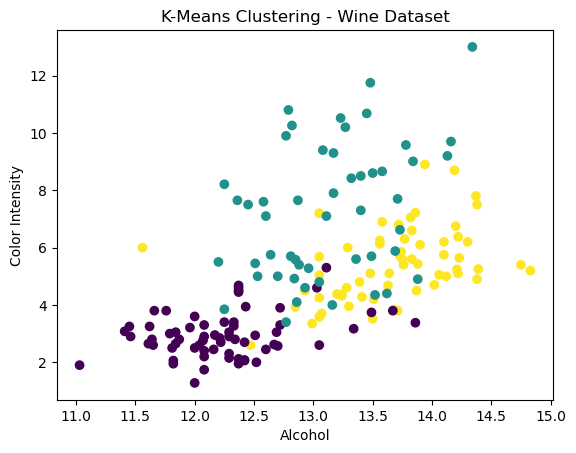

In [28]:
# Create a scatter plot using two meaningful features
plt.scatter(
    df["alcohol"],
    df["color_intensity"],
    c=df["Cluster"]
)

plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.title("K-Means Clustering - Wine Dataset")

plt.show()

## 31. PCA for Cluster Visualization

The Wine dataset contains many features.

**Principal Component Analysis (PCA)** can reduce high-dimensional data into fewer dimensions.

In this project, PCA is used **only for visualization**.

The K-Means model was already trained using all scaled features.

In [29]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object with two principal components
pca = PCA(n_components=2)

# Transform scaled data into two dimensions
x_pca = pca.fit_transform(x_scaled)

print("PCA Data:")
print(x_pca)

PCA Data:
[[ 3.31677142 -1.48755507]
 [ 2.22615942  0.30709265]
 [ 2.51357372 -0.99545081]
 [ 3.75236817 -2.80041064]
 [ 1.02532569 -0.89016934]
 [ 3.0490766  -2.16099802]
 [ 2.45744759 -1.20360372]
 [ 2.06522721 -1.63690285]
 [ 2.52378093 -0.97512693]
 [ 2.75983892 -0.81968681]
 [ 3.48719748 -1.34504736]
 [ 1.76544805 -0.63583226]
 [ 2.12731654 -0.69960189]
 [ 3.46411901 -1.17333508]
 [ 4.30961689 -2.14500863]
 [ 2.41847583 -1.09219827]
 [ 2.17135281 -2.36039709]
 [ 1.90336713 -1.65920831]
 [ 3.53777816 -2.55674654]
 [ 2.09208963 -1.09055242]
 [ 1.1082531  -0.25723828]
 [ 2.55578081  0.0619026 ]
 [ 1.67235041  0.49866586]
 [ 1.7882486   0.29606515]
 [ 1.01300854 -0.95970349]
 [ 1.79452951 -0.70563522]
 [ 1.25458102  0.07034425]
 [ 2.20586355 -0.71695646]
 [ 2.26951099 -0.22055584]
 [ 2.51418724 -1.27287106]
 [ 2.68315034 -1.50451988]
 [ 1.64556775 -0.07899022]
 [ 1.90785714 -1.6623771 ]
 [ 1.42534461 -0.72039052]
 [ 1.92204166 -0.20147097]
 [ 1.39939143 -0.67822113]
 [ 1.14262569 -0.1

## 32. Plot PCA Cluster Visualization

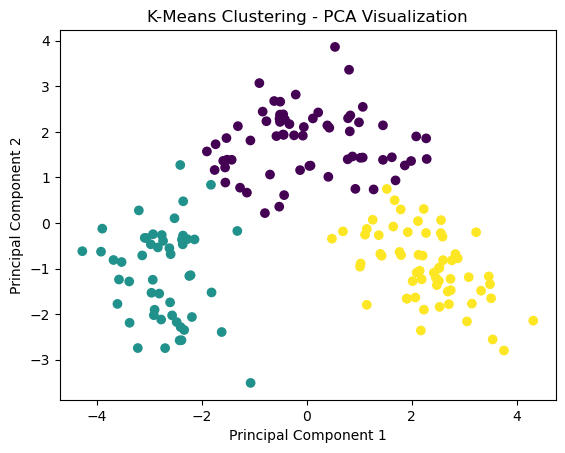

In [30]:
# Plot the two principal components
plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=cluster_prediction
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering - PCA Visualization")

plt.show()

## 33. Calculate Final Silhouette Score

In [31]:
# Calculate final cluster quality
silhouette = silhouette_score(
    x_scaled,
    cluster_prediction
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.2839251519711716


### Silhouette Score Interpretation

**Near +1:** Clusters are well separated.

**Near 0:** Clusters overlap.

**Near -1:** Some observations may be assigned to unsuitable clusters.

A higher score generally indicates better cluster cohesion and separation.

## 34. Display Model Information

In [32]:
# Display final model information
print("Number of Clusters:", kmeans_model.n_clusters)

print("Number of Iterations:", kmeans_model.n_iter_)

print("WCSS:", kmeans_model.inertia_)

print("Cluster Centers:")

print(kmeans_model.cluster_centers_)

Number of Clusters: 3
Number of Iterations: 3
WCSS: 1273.8167838452468
Cluster Centers:
[[-0.91988607 -0.39695639 -0.49504728  0.16472267 -0.48504577 -0.06965718
   0.02730756 -0.03907752  0.06326927 -0.89403967  0.46422461  0.28065682
  -0.75115528]
 [ 0.17344088  0.8665079   0.18464308  0.51859589 -0.0659088  -0.97372759
  -1.20986808  0.7204542  -0.77422991  0.94936202 -1.15934395 -1.28882801
  -0.40536161]
 [ 0.83519851 -0.3014711   0.37313568 -0.60910433  0.57195614  0.88832498
   0.98243083 -0.56070697  0.5798889   0.15893632  0.474622    0.77848419
   1.13932024]]


### Model Information

**n_clusters:** Final number of clusters.

**n_iter_:** Number of iterations used before convergence.

**inertia_:** Final WCSS value.

**cluster_centers_:** Final centroid positions in scaled feature space.

## 35. Display Complete Cluster Summary

In [33]:
print("Number of Clusters:", kmeans_model.n_clusters)

print("\nCluster Counts:")

print(df["Cluster"].value_counts().sort_index())

print("\nCluster Analysis:")

print(df.groupby("Cluster").mean())

print("\nSilhouette Score:", silhouette)

print("\nWCSS:", kmeans_model.inertia_)

Number of Clusters: 3

Cluster Counts:
Cluster
0    65
1    51
2    61
Name: count, dtype: int64

Cluster Analysis:
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
Cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.668689    2.003934  2.469344          17.486885  107.688525   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
Cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.845082    3.000492              0.292951         1.919180   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  
Cluster                                   

## 36. K-Means Advantages

- Simple to understand and implement.
- Fast for many tabular clustering problems.
- Scales better than hierarchical clustering for larger datasets.
- Cluster centroids are useful for profiling.
- Works well when clusters are compact and reasonably separated.

## 37. K-Means Limitations

- K must be selected before final training.
- Sensitive to feature scale.
- Sensitive to extreme outliers.
- Initial centroid positions can affect results.
- Performs poorly for some irregularly shaped clusters.
- Primarily designed around numerical distance-based data.
- Cluster labels do not have predefined meanings.

## 38. K-Means vs Hierarchical Clustering

### K-Means

- Requires K before final model training.
- Uses centroids.
- Iteratively reassigns observations.
- Generally suitable for larger datasets.
- Does not produce a dendrogram.

### Hierarchical Clustering

- Builds a hierarchy of clusters.
- Uses linkage methods.
- Produces a dendrogram.
- Can become computationally expensive for large datasets.
- Cluster selection can be examined through dendrogram cuts.

## 39. Complete K-Means Workflow

Load Dataset  
↓  
Understand Dataset  
↓  
Check Data Quality  
↓  
Create Preprocessing Examples  
↓  
Handle Missing Values  
↓  
Remove Duplicates  
↓  
Detect and Handle Outliers  
↓  
Validate Data  
↓  
Select x  
↓  
Feature Scaling  
↓  
Understand K-Means Process  
↓  
Elbow Method  
↓  
Silhouette Score  
↓  
Select K  
↓  
Create K-Means Model  
↓  
Train Model  
↓  
Predict Clusters  
↓  
Add Cluster Labels  
↓  
Check Cluster Counts  
↓  
Study Centroids  
↓  
Convert Centroids to Original Scale  
↓  
Cluster Profiling  
↓  
Two-Feature Visualization  
↓  
PCA Visualization  
↓  
Final Evaluation  
↓  
Complete Cluster Summary

## 40. Key Concepts Summary

- K-Means is an unsupervised clustering algorithm.
- K represents the number of clusters.
- A centroid represents the center of a cluster.
- K-Means commonly uses Euclidean distance.
- Feature scaling is important for distance-based algorithms.
- StandardScaler places features on comparable scales.
- K-Means minimizes Within-Cluster Sum of Squares.
- `inertia_` represents WCSS in Scikit-learn.
- The Elbow Method studies WCSS reduction for different K values.
- Silhouette Score evaluates cohesion and separation.
- K should not be selected randomly.
- `k-means++` improves initial centroid selection.
- `n_init` performs multiple initializations.
- Cluster labels are identifiers, not rankings.
- Cluster Profiling explains the characteristics of clusters.
- PCA can be used to visualize high-dimensional clustering results.
- Outliers can strongly affect centroid-based clustering.